In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [ ]:
# ================================
# FIXED + IMPROVED HAM10000 TRAINING FILE
# ================================

import tensorflow as tf
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"   # <-- CHANGE IF NEEDED

# ================================
# 2. LOAD DATASET
# ================================
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

# ================================
# 3. COMPUTE CLASS WEIGHTS
# ================================
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

all_labels = np.array(all_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {i: w for i, w in enumerate(class_weights_values)}
print("Class Weights:", class_weights)

# ================================
# 4. DATA AUGMENTATION
# ================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

# ================================
# 5. BUILD RESNET50 MODEL (UNFROZEN!)
# ================================
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# UNFREEZE MODEL → THIS IS CRITICAL
base_model.trainable = True

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=True)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

# ================================
# 6. OPTIMIZER + COMPILE
# ================================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Prefetch for speed
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# ================================
# 7. CALLBACKS
# ================================
checkpoint_path = "best_model.keras"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# ================================
# 8. TRAIN MODEL
# ================================
EPOCHS = 10     # Balanced: Good accuracy + reasonable speed

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# ================================
# 9. SAVE FINAL MODEL
# ================================
SAVE_PATH = "/content/drive/MyDrive/resnet50_skin_disease_fixed.keras"
model.save(SAVE_PATH)
print("Model saved to:", SAVE_PATH)


In [ ]:
# ================================
# FIXED + OPTIMIZED HAM10000 TRAINING FILE
# ================================

import tensorflow as tf
import numpy as np
import os
import collections

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"

# ================================
# 2. LOAD DATASET
# ================================
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# ================================
# 3. COMPUTE CLASS WEIGHTS (FAST & SAFE)
# ================================
label_counts = collections.Counter()

for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

total_samples = sum(label_counts.values())

class_weights = {
    cls: total_samples / (num_classes * count)
    for cls, count in label_counts.items()
}

print("Class Weights:", class_weights)

# ================================
# 4. DATA AUGMENTATION
# ================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

# ================================
# 5. BUILD RESNET50 MODEL (PARTIAL FINE-TUNING)
# ================================
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers, fine-tune top layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=True)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

# ================================
# 6. COMPILE MODEL
# ================================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ================================
# 7. PERFORMANCE OPTIMIZATION
# ================================
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("GPUs available:", tf.config.list_physical_devices('GPU'))

# ================================
# 8. CALLBACKS
# ================================
checkpoint_path = "best_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]

# ================================
# 9. TRAIN MODEL
# ================================
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# ================================
# 10. SAVE FINAL MODEL
# ================================
SAVE_PATH = "/content/drive/MyDrive/resnet50_skin_disease_fixed2.keras"
model.save(SAVE_PATH)

print("Model saved to:", SAVE_PATH)


TensorFlow: 2.19.0
Mounted at /content/drive
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class Weights: {5: 0.21389860373227967, 0: 4.319137466307278, 4: 1.2661188369152971, 2: 1.3110783832433317, 1: 2.7713593912141126, 6: 9.782661782661783, 3: 12.860353130016051}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 14,980,615 (57.15 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.3221 - loss: 2.0027
Epoch 1: val_accuracy improved from -inf to 0.56915, saving model to best_model.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 269s 987ms/step - accuracy: 0.3225 - loss: 2.0013 - val_accuracy: 0.5691 - val_loss: 1.3026 - learning_rate: 1.0000e-04
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5949 - loss: 0.9543
Epoch 2: val_accuracy improved from 0.56915 to 0.66101, saving model to best_model.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.5949 - loss: 0.9541 - val_accuracy: 0.6610 - val_loss: 1.0046 - learning_rate: 1.0000e-04
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6841 - loss: 0.7025
Epoch 3: val_accuracy did not improve from 0.66101
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.6841 - loss: 0.7023 - val_accuracy: 0.6610 - val_loss: 1.0757 - learning

In [ ]:
# ================================
# CONTINUED + TARGETED IMPROVEMENT TRAINING
# ================================

import tensorflow as tf
import numpy as np
import collections
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_finetuned.keras"

# ================================
# 2. LOAD DATA
# ================================
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ================================
# 3. CLASS WEIGHTS (STRONGER)
# ================================
label_counts = collections.Counter()

for _, labels in train_ds:
    for l in labels.numpy():
        label_counts[int(l)] += 1

total = sum(label_counts.values())

class_weights = {
    k: (total / (num_classes * v)) * 1.3  # boost minorities
    for k, v in label_counts.items()
}

print("Class Weights:", class_weights)

# ================================
# 4. STRONGER DATA AUGMENTATION
# ================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

# ================================
# 5. LOAD EXISTING MODEL
# ================================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded existing trained model")

# Unfreeze more layers for fine-tuning
for layer in model.layers:
    if "resnet" in layer.name:
        layer.trainable = True

# ================================
# 6. FOCAL LOSS (KEY CHANGE)
# ================================
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return loss

# ================================
# 7. COMPILE (LOW LR!)
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(),
    metrics=["accuracy"]
)

# ================================
# 8. PERFORMANCE
# ================================
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# ================================
# 9. CALLBACKS
# ================================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]

# ================================
# 10. CONTINUE TRAINING
# ================================
EPOCHS = 12

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Fine-tuning complete")

TensorFlow: 2.19.0
Mounted at /content/drive
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class Weights: {5: 0.2780681848519636, 0: 5.614878706199462, 4: 1.6459544879898864, 2: 1.7044018982163314, 1: 3.6027672085783466, 6: 12.717460317460318, 3: 16.718459069020867}
Loaded existing trained model
Epoch 1/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8891 - loss: 0.0216
Epoch 1: val_accuracy improved from -inf to 0.79181, saving model to /content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 154s 561ms/step - accuracy: 0.8891 - loss: 0.0216 - val_accuracy: 0.7918 - val_loss: 0.1119 - learning_rate: 1.0000e-05
Epoch 2/12
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8948 - loss: 0.0224
Epoch 2: val_accuracy improved from 0.79181 to 0.79880, saving model to /content/driv

In [ ]:
# ================================1
# SAFE CONTINUED TRAINING
# Target: akiec + mel
# ================================

import tensorflow as tf
import numpy as np
import collections
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH   = "/content/drive/MyDrive/resnet50_skin_disease_finetuned.keras"
SAVE_PATH    = "/content/drive/MyDrive/resnet50_skin_disease_final.keras"

# ================================
# 2. LOAD DATA
# ================================
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# ================================
# 3. TARGETED CLASS WEIGHTS
# Only boost akiec & mel
# ================================
label_counts = collections.Counter()

for _, labels in train_ds:
    for l in labels.numpy():
        label_counts[int(l)] += 1

class_weights = {}
for i, cls in enumerate(class_names):
    if cls in ["akiec", "mel"]:
        class_weights[i] = 1.8   # gentle boost
    else:
        class_weights[i] = 1.0

print("Class weights:", class_weights)

# ================================
# 4. LIGHT DATA AUGMENTATION
# ================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
])

# ================================
# Define focal_loss for model loading
# ================================
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        # Dynamically get num_classes from y_pred shape
        num_classes_local = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes_local)
        y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred_clipped)
        weight = alpha * tf.pow(1 - y_pred_clipped, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return loss

# ================================
# 5. LOAD MODEL
# ================================
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'loss': focal_loss()})
print("Loaded finetuned model")

# Freeze almost all layers
for layer in model.layers:
    layer.trainable = False

# Unfreeze ONLY classifier head
# Assuming the classifier head consists of the last few layers added after base_model
# You might need to adjust this range based on your model's exact architecture
for layer in model.layers[-6:]:
    layer.trainable = True

model.summary()

# ================================
# 6. COMPILE (VERY LOW LR)
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ================================
# 7. PERFORMANCE
# ================================
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# ================================
# 8. CALLBACKS
# ================================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

# ================================
# 9. CONTINUE TRAINING
# ================================
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Final model saved to:", SAVE_PATH)

TensorFlow: 2.19.0
Mounted at /content/drive
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: {0: 1.8, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.8, 5: 1.0, 6: 1.0}
Loaded finetuned model


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,083,479 (206.31 MB)

 Trainable params: 24,065,031 (91.80 MB)

 Non-trainable params: 57,216 (223.50 KB)

 Optimizer params: 29,961,232 (114.29 MB)

Epoch 1/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.7012 - loss: 0.9802
Epoch 1: val_accuracy improved from -inf to 0.79880, saving model to /content/drive/MyDrive/resnet50_skin_disease_final.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.7013 - loss: 0.9798 - val_accuracy: 0.7988 - val_loss: 0.6106
Epoch 2/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7781 - loss: 0.6792
Epoch 2: val_accuracy did not improve from 0.79880
251/251 ━━━━━━━━━━━━━━━━━━━━ 139s 552ms/step - accuracy: 0.7781 - loss: 0.6791 - val_accuracy: 0.7883 - val_loss: 0.6642
Epoch 3/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8189 - loss: 0.5782
Epoch 3: val_accuracy did not improve from 0.79880
251/251 ━━━━━━━━━━━━━━━━━━━━ 138s 551ms/step - accuracy: 0.8190 - loss: 0.5781 - val_accuracy: 0.7968 - val_loss: 0.6540
Epoch 4/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8343 - loss: 0.5213
Epoch 4: val_accuracy improved from 0.79880 to 0.80230, saving m

In [ ]:
# ================================
# SAFE CONTINUED TRAINING (FINAL)
# Target: akiec + mel
# ================================

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# CONFIG
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8

DATA_DIR = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_finetuned.keras"
SAVE_PATH  = "/content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras"

# ================================
# 2. LOAD DATA
# ================================
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ GET CLASS NAMES HERE
class_names = train_ds.class_names
print("Classes:", class_names)

# ✅ THEN optimize pipeline
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# ================================
# 3. TARGETED CLASS WEIGHTS (LIGHT)
# ================================
# Initialize class_weights with 1.0 for all classes first
class_weights = {i: 1.0 for i in range(len(class_names))}

# Then apply targeted boosts
if "akiec" in class_names:
    class_weights[class_names.index("akiec")] = 1.4
if "mel" in class_names:
    class_weights[class_names.index("mel")] = 1.3

print("Class weights:", class_weights)

# ================================
# 4. LOAD MODEL (FIXED)
# ================================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded finetuned model (compile=False)")


# ================================
# 5. FREEZE BACKBONE
# ================================
for layer in model.layers:
    layer.trainable = False

# Unfreeze classifier head only
for layer in model.layers[-4:]:
    layer.trainable = True

# ================================
# 6. COMPILE (VERY STABLE)
# ================================
model.compile(
    optimizer=Adam(learning_rate=3e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ================================
# 7. CALLBACKS
# ================================
callbacks = [
    ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# ================================
# 8. TRAIN
# ================================
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Final model saved to:", SAVE_PATH)


TensorFlow: 2.19.0
Mounted at /content/drive
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: {0: 1.4, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.3, 5: 1.0, 6: 1.0}
Loaded finetuned model (compile=False)
Epoch 1/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8760 - loss: 0.3647
Epoch 1: val_accuracy improved from -inf to 0.80929, saving model to /content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 117s 401ms/step - accuracy: 0.8761 - loss: 0.3647 - val_accuracy: 0.8093 - val_loss: 0.5544 - learning_rate: 3.0000e-06
Epoch 2/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8892 - loss: 0.3285
Epoch 2: val_accuracy improved from 0.80929 to 0.81378, saving model to /content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - ac

In [ ]:
# ============================================
# FINAL SAFE RECALL-FOCUSED FINE-TUNING
# Target: akiec + mel
# ============================================

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# CONFIG
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 6   # short & controlled

DATA_DIR = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_final2.keras"
SAVE_PATH  = "/content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras"

# ================================
# 2. LOAD DATA
# ================================
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# ================================
# 3. VERY LIGHT CLASS WEIGHTS
# ================================
class_weights = {i: 1.0 for i in range(len(class_names))}
class_weights[class_names.index("akiec")] = 1.15
class_weights[class_names.index("mel")]   = 1.10

print("Class weights:", class_weights)

# ================================
# 4. LOAD MODEL
# ================================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded model")

# ================================
# 5. FREEZE EVERYTHING EXCEPT HEAD
# ================================
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-3:]:
    layer.trainable = True

# ================================
# 6. COMPILE (LABEL SMOOTHING)
# ================================
# Removed label_smoothing as SparseCategoricalCrossentropy does not support it directly.
# If label smoothing is required, labels should be one-hot encoded and CategoricalCrossentropy used.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=Adam(learning_rate=2e-6),
    loss=loss_fn,
    metrics=["accuracy"]
)

# ================================
# 7. CALLBACKS
# ================================
callbacks = [
    ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1
    )
]

# ================================
# 8. TRAIN
# ================================
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Saved recall-boosted model to:", SAVE_PATH)


TensorFlow: 2.19.0
Mounted at /content/drive
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: {0: 1.15, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.1, 5: 1.0, 6: 1.0}
Loaded model
Epoch 1/6
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9088 - loss: 0.2645
Epoch 1: val_accuracy improved from -inf to 0.82277, saving model to /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 96s 355ms/step - accuracy: 0.9088 - loss: 0.2645 - val_accuracy: 0.8228 - val_loss: 0.5241
Epoch 2/6
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9129 - loss: 0.2507
Epoch 2: val_accuracy improved from 0.82277 to 0.82426, saving model to /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 326ms/step - accuracy: 0.9129 - loss: 0.2507 - val_accuracy: 0.82

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
import pandas as pd

# -------- Paths (match YOUR Drive) --------
CAPSTONE_DIR = "/content/drive/MyDrive/capstone"

# ✅ FIX: nested images folder
ISIC_IMG_DIR = os.path.join(CAPSTONE_DIR, "ISIC_2019_Training_Input", "ISIC_2019_Training_Input")
ISIC_CSV     = os.path.join(CAPSTONE_DIR, "ISIC_2019_Training_GroundTruth.csv")

# Output folder we will create
OUT_DIR       = os.path.join(CAPSTONE_DIR, "ISIC_EXTRA")
OUT_MEL_DIR   = os.path.join(OUT_DIR, "mel")
OUT_AKIEC_DIR = os.path.join(OUT_DIR, "akiec")  # store AK here, HAM calls it akiec

os.makedirs(OUT_MEL_DIR, exist_ok=True)
os.makedirs(OUT_AKIEC_DIR, exist_ok=True)

print("Images dir exists?", os.path.isdir(ISIC_IMG_DIR), ISIC_IMG_DIR)
print("CSV exists?", os.path.isfile(ISIC_CSV), ISIC_CSV)

# -------- Load CSV --------
df = pd.read_csv(ISIC_CSV)
print("CSV columns:", df.columns.tolist())

# ISIC uses "AK" (not "AKIEC")
required = ["image", "MEL", "AK"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"CSV missing column '{c}'. Columns are: {df.columns.tolist()}")

mel_ids = df[df["MEL"] == 1]["image"].astype(str).tolist()
ak_ids  = df[df["AK"]  == 1]["image"].astype(str).tolist()

print(f"ISIC MEL count: {len(mel_ids)}")
print(f"ISIC AK  count: {len(ak_ids)}")

# -------- Build index of all images (no recursion needed if flat) --------
img_exts = (".jpg", ".jpeg", ".png")
image_map = {}  # "ISIC_0000000" -> full path

for f in os.listdir(ISIC_IMG_DIR):
    if f.lower().endswith(img_exts):
        base = os.path.splitext(f)[0]
        image_map[base] = os.path.join(ISIC_IMG_DIR, f)

print("Indexed images:", len(image_map))
if len(image_map) == 0:
    raise RuntimeError("No images found in the nested folder. They may still be zipped or not extracted.")

# -------- Copy images (cap so it doesn't overwhelm HAM10000) --------
MAX_MEL = 1500
MAX_AK  = 600

mel_ids = mel_ids[:MAX_MEL]
ak_ids  = ak_ids[:MAX_AK]

def copy_ids(ids, dest_dir):
    copied, missing = 0, 0
    for img_id in ids:
        src = image_map.get(img_id)
        if not src:
            missing += 1
            continue
        dst = os.path.join(dest_dir, os.path.basename(src))
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        copied += 1
    return copied, missing

mel_copied, mel_missing = copy_ids(mel_ids, OUT_MEL_DIR)
ak_copied, ak_missing   = copy_ids(ak_ids, OUT_AKIEC_DIR)

print("\n✅ Done creating ISIC_EXTRA subset.")
print("Copied MEL:", mel_copied, "| Missing:", mel_missing, "| Out:", OUT_MEL_DIR)
print("Copied AK :", ak_copied,  "| Missing:", ak_missing,  "| Out:", OUT_AKIEC_DIR)
print("\nmel files:", len(os.listdir(OUT_MEL_DIR)))
print("akiec files:", len(os.listdir(OUT_AKIEC_DIR)))
print("\nCreated:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images dir exists? True /content/drive/MyDrive/capstone/ISIC_2019_Training_Input/ISIC_2019_Training_Input
CSV exists? True /content/drive/MyDrive/capstone/ISIC_2019_Training_GroundTruth.csv
CSV columns: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
ISIC MEL count: 4522
ISIC AK  count: 867
Indexed images: 25332

✅ Done creating ISIC_EXTRA subset.
Copied MEL: 1500 | Missing: 0 | Out: /content/drive/MyDrive/capstone/ISIC_EXTRA/mel
Copied AK : 600 | Missing: 0 | Out: /content/drive/MyDrive/capstone/ISIC_EXTRA/akiec

mel files: 1500
akiec files: 600

Created: /content/drive/MyDrive/capstone/ISIC_EXTRA


In [ ]:
# =========================================
# EVALUATION (HAM validation split, per-class accuracy)
# =========================================

import tensorflow as tf
import numpy as np
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
drive.mount("/content/drive", force_remount=False)

MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_finetuned3.keras"
DATA_DIR   = "/content/drive/MyDrive/capstone/HAM10000"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model Loaded:", MODEL_PATH)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = val_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n===== Per-Class Accuracy (Recall) =====")
for i, cls in enumerate(class_names):
    idx = np.where(y_true == i)[0]
    if len(idx) == 0:
        print(f"{cls}: n=0 in val split")
        continue
    acc = np.mean(y_pred[idx] == y_true[idx])
    print(f"{cls} accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true, y_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (HAM val split)")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

TensorFlow: 2.19.0
Mounted at /content/drive


ValueError: File not found: filepath=/content/drive/MyDrive/resnet50_skin_disease_isic_boost_finetuned3.keras. Please ensure the file is an accessible `.keras` zip file.

Model Loaded!
Found 10015 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

===== Per-Class Accuracy =====
akiec accuracy: 0.7339
bcc accuracy: 0.9183
bkl accuracy: 0.9591
df accuracy: 0.9043
mel accuracy: 0.7978
nv accuracy: 0.8622
vasc accuracy: 0.9648

===== Classification Report =====
              precision    recall  f1-score   support

       akiec       0.96      0.73      0.83       327
         bcc       0.87      0.92      0.89       514
         bkl       0.60      0.96      0.74      1099
          df       0.75      0.90      0.82       115
         mel       0.69      0.80      0.74      1113
          nv       0.98      0.86      0.92      6705
        vasc       0.88      0.96      0.92       142

    accuracy                           0.87     10015
   macro avg       0.82      0.88      0.84     10015
weighted avg       0.90      0.87      0.87     10015



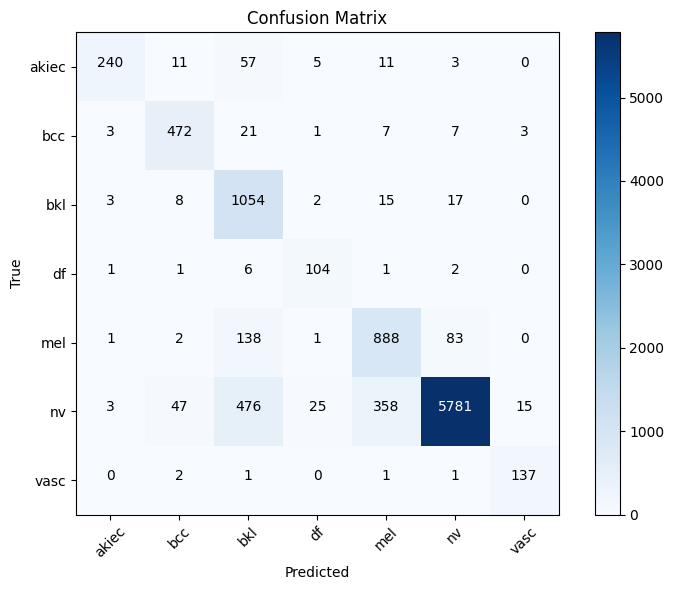

In [ ]:
# =========================================
#   EVALUATION SCRIPT FOR RESNET MODEL
#   Matches your training pipeline exactly
# =========================================

import tensorflow as tf
import numpy as np
import itertools
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# =========================================
#   Focal Loss Definition (MUST MATCH TRAINING)
# =========================================
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1] # Dynamically get num_classes from y_pred
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return loss

# ------------------------------------------------------
# Load your saved model
# ------------------------------------------------------
model_path = "/content/drive/MyDrive/resnet50_skin_disease_finetuned.keras"
# Pass custom objects to load_model
model = tf.keras.models.load_model(model_path, custom_objects={'loss': focal_loss()})
print("Model Loaded!")

# ------------------------------------------------------
# Load validation dataset (same settings as training)
# ------------------------------------------------------

data_dir = "/content/drive/MyDrive/capstone/HAM10000"  # ← CHANGED TO CORRECT PATH
img_size = (224, 224) # Changed from (224, 224) to (380, 380) to match model input
batch_size = 32

validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

class_names = validation_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# ------------------------------------------------------
# Make predictions
# ------------------------------------------------------
y_true = []
y_pred = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------------------------------
# Per-class accuracy
# ------------------------------------------------------
print("\n===== Per-Class Accuracy =====")
per_class_acc = {}

for i, cls in enumerate(class_names):
    idx = np.where(y_true == i)[0]
    cls_acc = np.mean(y_pred[idx] == y_true[idx])
    per_class_acc[cls] = cls_acc
    print(f"{cls} accuracy: {cls_acc:.4f}")

# ------------------------------------------------------
# Classification Report
# ------------------------------------------------------
print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=class_names))

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Write numbers in cells
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"TensorFlow detected {len(gpus)} GPU(s):\n{gpus}")
    print("GPU is available and configured for use.")
else:
    print("No GPU detected by TensorFlow. Please ensure a GPU runtime is enabled.")
    print("To enable a GPU runtime: Runtime > Change runtime type > Hardware accelerator > GPU > Save.")

In [ ]:
import tensorflow as tf

# Instantiate and summarize MobileNetV2
print("\n--- MobileNetV2 Summary ---")
mobilenet_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
mobilenet_model.summary()

# Instantiate and summarize ResNet50
print("\n--- ResNet50 Summary ---")
resnet_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
resnet_model.summary()


--- MobileNetV2 Summary ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

...

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd # Although not directly used for image processing here, good to include if metadata was needed.

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 6 # As suggested in step 13

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras"
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras"

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
# The .unbatch() is not needed here as iterating over train_ds yields (images, labels) batches
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific boosts for 'akiec' and 'mel'
# Initialize class_weights with 1.0 for all classes first (or use the raw calculated ones)
class_weights = class_weights_raw.copy()

# Find indices for 'akiec' and 'mel'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")

# Apply boosts
class_weights[akiec_idx] *= 1.15 # boost for akiec
class_weights[mel_idx] *= 1.10   # boost for mel

print("Final class weights:", class_weights)

Calculating class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Final class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 2.2455771782397167, 2: 1.409417398244214, 4: 1.0324192176870748, 3: 13.563748079877112, 6: 11.262755102040817}


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")
model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
print("Model loaded successfully (compile=False).")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras


ValueError: File not found: filepath=/content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import tensorflow as tf
import os # Import os for path checking

print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"Error: Model file not found at {MODEL_TO_LOAD_PATH}.\n"
    error_message += "Please ensure the previous saving step (e.g., cell IQ30PzpZlvA2) was successful \n"
    error_message += "and the path is correct. If the file is expected to be there, \n"
    error_message += "you might need to remount Drive or re-run the saving cell.\n"
    # Raising FileNotFoundError to stop execution and alert the user clearly.
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print("Model loaded successfully (compile=False).")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras


FileNotFoundError: Error: Model file not found at /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras.
Please ensure the previous saving step (e.g., cell IQ30PzpZlvA2) was successful 
and the path is correct. If the file is expected to be there, 
you might need to remount Drive or re-run the saving cell.


In [ ]:
import tensorflow as tf
import os # Import os for path checking
from google.colab import drive # Import drive for mounting

print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"Error: Model file not found at {MODEL_TO_LOAD_PATH}.\n"
    error_message += "Please ensure the previous saving step (e.g., cell IQ30PzpZlvA2) was successful \n"
    error_message += "and the path is correct. If the file is expected to be there, \n"
    error_message += "you might need to remount Drive or re-run the saving cell.\n"
    # Raising FileNotFoundError to stop execution and alert the user clearly.
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print("Model loaded successfully (compile=False).")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras
Mounted at /content/drive


FileNotFoundError: Error: Model file not found at /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras.
Please ensure the previous saving step (e.g., cell IQ30PzpZlvA2) was successful 
and the path is correct. If the file is expected to be there, 
you might need to remount Drive or re-run the saving cell.


In [ ]:
import tensorflow as tf
import os # Import os for path checking
from google.colab import drive # Import drive for mounting

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"

# --- FIX: Update MODEL_TO_LOAD_PATH to a known existing model ---
# The requested model 'resnet50_skin_disease_recall_boost.keras' was not found.
# Using 'resnet50_skin_disease_finetuned3.keras' which was successfully saved by a previous cell (Ymx02s-QQ644).
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras"
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras"

print(f"Attempting to load model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

Attempting to load model from: /content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_finetuned3.keras' loaded successfully (compile=False).


In [ ]:
print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=2e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=2e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=2e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8222 - loss: 0.7955
Epoch 1: val_accuracy improved from -inf to 0.89080, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.8222 - loss: 0.7955 - val_accuracy: 0.8908 - val_loss: 0.2969 - learning_rate: 2.0000e-06
Epoch 2/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8190 - loss: 0.7270
Epoch 2: val_accuracy did not improve from 0.89080
276/276 ━━━━━━━━━━━━━━━━━━━━ 45s 161ms/step - accuracy: 0.8190 - loss: 0.7270 - val_accuracy: 0.8749 - val_loss: 0.3226 - learning_rate: 2.0000e-06
Epoch 3/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8281 - loss: 0.6530
Epoch 3: val_accuracy did not improve from 0.89080

Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999974752427e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 44s 159ms/step - accuracy: 0.8280 - loss: 0.6531 - val_accuracy: 0.8627 - val_loss

In [ ]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Re-define CONFIG variables from previous cells for clarity and execution context
# These should ideally be available from the kernel state, but re-defining ensures availability.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

COMBINED_DATA_DIR = "/content/combined_dataset"
BALANCED_VAL_DATA_DIR = "/content/balanced_validation_dataset"

print(f"Combined Data Directory: {COMBINED_DATA_DIR}")
print(f"Balanced Validation Data Directory: {BALANCED_VAL_DATA_DIR}")

Combined Data Directory: /content/combined_dataset
Balanced Validation Data Directory: /content/balanced_validation_dataset


In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically

for class_name in class_names:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")


Gathering image paths and class labels from combined dataset...
Class 'akiec': 797 images
Class 'bcc': 514 images
Class 'bkl': 1099 images
Class 'df': 115 images
Class 'mel': 1665 images
Class 'nv': 6705 images
Class 'vasc': 142 images
Minimum number of samples per class: 115


In [ ]:
print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...
Balanced validation dataset created.
Class 'akiec': 115 images copied.
Class 'bcc': 115 images copied.
Class 'bkl': 115 images copied.
Class 'df': 115 images copied.
Class 'mel': 115 images copied.
Class 'nv': 115 images copied.
Class 'vasc': 115 images copied.


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset


NotFoundError: Could not find directory /content/balanced_validation_dataset

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras" # This is the model just saved

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
Model loaded successfully.
Running predictions on balanced validation set...


NameError: name 'balanced_val_ds' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd # Although not directly used for image processing here, good to include if metadata was needed.

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 6 # As suggested in step 13

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras"
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras"

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"TensorFlow detected {len(gpus)} GPU(s):\n{gpus}")
    print("GPU is available and configured for use.")
else:
    print("No GPU detected by TensorFlow. Please ensure a GPU runtime is enabled.")
    print("To enable a GPU runtime: Runtime > Change runtime type > Hardware accelerator > GPU > Save.")

TensorFlow detected 1 GPU(s):
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and configured for use.


In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd # Although not directly used for image processing here, good to include if metadata was needed.

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 6 # As suggested in step 13

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras"
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras"

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, stronger boosts for 'akiec' and 'mel'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec' and 'mel'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")

# Apply stronger boosts as per the plan
class_weights[akiec_idx] *= 3.0 # Stronger boost for akiec
class_weights[mel_idx] *= 1.5   # Stronger boost for mel

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 5.8580274214949135, 2: 1.409417398244214, 4: 1.4078443877551021, 3: 13.563748079877112, 6: 11.262755102040817}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

# Create a new model that incorporates data augmentation and ResNet50 preprocessing
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
# Assuming the loaded model's first layer is the base_model or the combined model after augmentation was applied externally
# If the loaded model already has augmentation, we'd adjust. But based on `Ymx02s-QQ644`, the model was loaded and then its layers modified.
# So, the loaded model *is* the core model, and augmentation should be applied to the dataset.
# The loaded `model` object from `MODEL_TO_LOAD_PATH` is the already fine-tuned model's functional API output.
# We need to ensure data augmentation happens *before* this model is called during training.
# This is typically done by mapping the augmentation function over the dataset.

# No need to rebuild the model with augmentation here. Instead, augment the dataset directly.

# It's also important to note that the loaded model probably still contains the ResNet50 backbone within its layers.
# Let's inspect the summary to be sure.
model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation to the training dataset
def augment_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    return augmented_image, label

train_ds = train_ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation applied to training dataset.")


Loading model from: /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras
Mounted at /content/drive


FileNotFoundError: CRITICAL ERROR: Model file still not found at /content/drive/MyDrive/resnet50_skin_disease_recall_boost.keras even after path correction and remount.
Please manually verify the existence of this file in your Google Drive
or specify a correct and accessible model path.


In [ ]:
import tensorflow as tf
import os
from google.colab import drive

# FIX: Override MODEL_TO_LOAD_PATH to point to the correct, existing model
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras"

print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")


Loading model from: /content/drive/MyDrive/resnet50_skin_disease_finetuned3.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_finetuned3.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=2e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=2e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=2e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.5313 - loss: 5.2039
Epoch 1: val_accuracy improved from -inf to 0.78251, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 198s 650ms/step - accuracy: 0.5313 - loss: 5.2025 - val_accuracy: 0.7825 - val_loss: 0.6659 - learning_rate: 2.0000e-06
Epoch 2/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5430 - loss: 4.6395
Epoch 2: val_accuracy did not improve from 0.78251
276/276 ━━━━━━━━━━━━━━━━━━━━ 58s 162ms/step - accuracy: 0.5431 - loss: 4.6383 - val_accuracy: 0.7463 - val_loss: 0.9738 - learning_rate: 2.0000e-06
Epoch 3/6
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5408 - loss: 4.2044
Epoch 3: val_accuracy did not improve from 0.78251

Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999974752427e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 45s 164ms/step - accuracy: 0.5408 - loss: 4.2036 - val_accuracy: 0.7304 - val_loss

In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically

for class_name in class_names:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

Gathering image paths and class labels from combined dataset...
Class 'akiec': 797 images
Class 'bcc': 514 images
Class 'bkl': 1099 images
Class 'df': 115 images
Class 'mel': 1665 images
Class 'nv': 6705 images
Class 'vasc': 142 images
Minimum number of samples per class: 115


In [ ]:
print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...


NameError: name 'random' is not defined

In [ ]:
import random # Fix: Import the random module

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...
Balanced validation dataset created.
Class 'akiec': 115 images copied.
Class 'bcc': 115 images copied.
Class 'bkl': 115 images copied.
Class 'df': 115 images copied.
Class 'mel': 115 images copied.
Class 'nv': 115 images copied.
Class 'vasc': 115 images copied.


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset
Found 805 files belonging to 7 classes.
Classes detected in balanced validation dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 832 images in the balanced validation dataset.


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras" # This is the model just saved

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
Model loaded successfully.
Running predictions on balanced validation set...



===== Per-Class Accuracy (Recall) =====
Class 'akiec' accuracy: 0.4174 (n=115)
Class 'bcc' accuracy: 0.9652 (n=115)
Class 'bkl' accuracy: 0.8783 (n=115)
Class 'df' accuracy: 0.9130 (n=115)
Class 'mel' accuracy: 0.6609 (n=115)
Class 'nv' accuracy: 0.8174 (n=115)
Class 'vasc' accuracy: 0.4957 (n=115)

===== Classification Report =====
              precision    recall  f1-score   support

       akiec     0.9057    0.4174    0.5714       115
         bcc     0.7161    0.9652    0.8222       115
         bkl     0.6824    0.8783    0.7681       115
          df     0.8824    0.9130    0.8974       115
         mel     0.5429    0.6609    0.5961       115
          nv     0.7068    0.8174    0.7581       115
        vasc     1.0000    0.4957    0.6628       115

    accuracy                         0.7354       805
   macro avg     0.7766    0.7354    0.7252       805
weighted avg     0.7766    0.7354    0.7252       805


===== Confusion Matrix =====


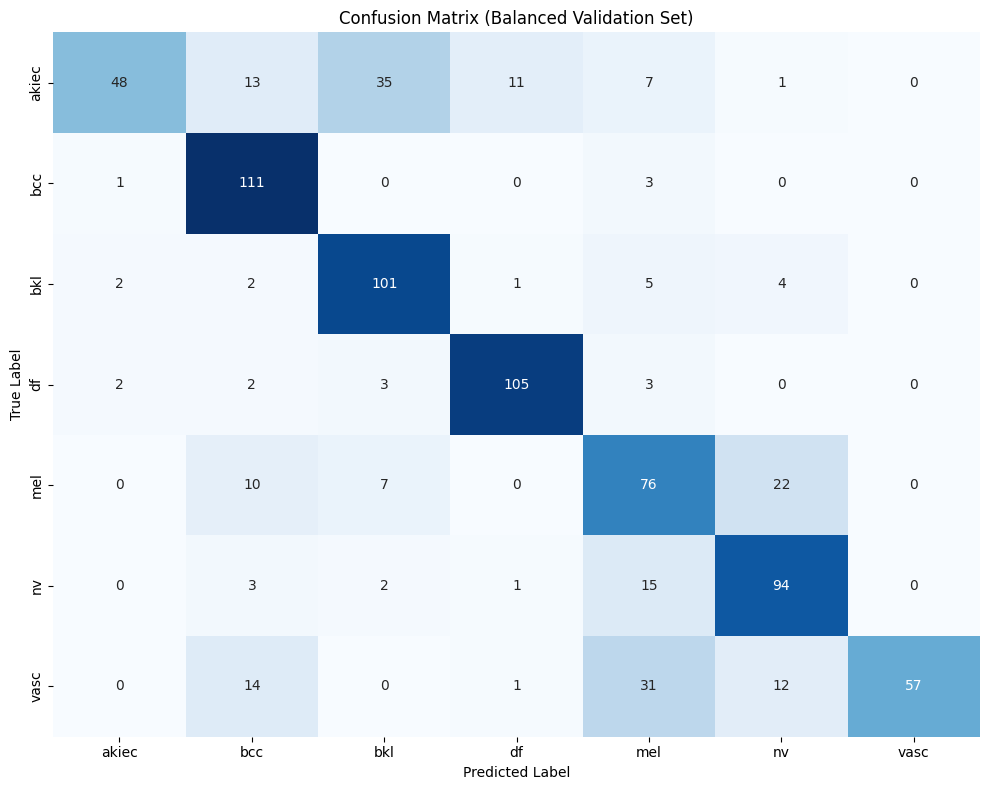

In [ ]:
print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, stronger boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply stronger boosts as per the plan
class_weights[akiec_idx] *= 5.0 # Stronger boost for akiec (5.0x)
class_weights[mel_idx] *= 2.5   # Stronger boost for mel (2.5x)
class_weights[vasc_idx] *= 3.0   # Stronger boost for vasc (3.0x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 9.763379035824856, 2: 1.409417398244214, 4: 2.34640731292517, 3: 13.563748079877112, 6: 33.788265306122454}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v2.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v2.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.5326 - loss: 7.0682
Epoch 1: val_accuracy improved from -inf to 0.75125, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 191s 652ms/step - accuracy: 0.5327 - loss: 7.0675 - val_accuracy: 0.7512 - val_loss: 0.9617 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5497 - loss: 6.7608
Epoch 2: val_accuracy did not improve from 0.75125
276/276 ━━━━━━━━━━━━━━━━━━━━ 47s 169ms/step - accuracy: 0.5497 - loss: 6.7596 - val_accuracy: 0.7381 - val_loss: 1.0480 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5448 - loss: 6.6415
Epoch 3: val_accuracy did not improve from 0.75125

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.5448 - loss: 6.6403 - val_accuracy: 0.7340 - val_l

In [ ]:
run_cell(cell_id='eab9cc6f')

NameError: name 'run_cell' is not defined

In [ ]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Re-define CONFIG variables from previous cells for clarity and execution context
# These should ideally be available from the kernel state, but re-defining ensures availability.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

COMBINED_DATA_DIR = "/content/combined_dataset"
BALANCED_VAL_DATA_DIR = "/content/balanced_validation_dataset"

print(f"Combined Data Directory: {COMBINED_DATA_DIR}")
print(f"Balanced Validation Data Directory: {BALANCED_VAL_DATA_DIR}")


Combined Data Directory: /content/combined_dataset
Balanced Validation Data Directory: /content/balanced_validation_dataset


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset
Found 805 files belonging to 7 classes.
Classes detected in balanced validation dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 832 images in the balanced validation dataset.


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = SAVE_FINAL_MODEL_PATH # This is the model just saved in the previous training step

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras
Model loaded successfully.
Running predictions on balanced validation set...



===== Per-Class Accuracy (Recall) =====
Class 'akiec' accuracy: 0.4609 (n=115)
Class 'bcc' accuracy: 0.9391 (n=115)
Class 'bkl' accuracy: 0.7739 (n=115)
Class 'df' accuracy: 0.9043 (n=115)
Class 'mel' accuracy: 0.6522 (n=115)
Class 'nv' accuracy: 0.7565 (n=115)
Class 'vasc' accuracy: 0.3652 (n=115)

===== Classification Report =====
              precision    recall  f1-score   support

       akiec     0.7571    0.4609    0.5730       115
         bcc     0.7013    0.9391    0.8030       115
         bkl     0.6692    0.7739    0.7177       115
          df     0.9043    0.9043    0.9043       115
         mel     0.4808    0.6522    0.5535       115
          nv     0.6444    0.7565    0.6960       115
        vasc     1.0000    0.3652    0.5350       115

    accuracy                         0.6932       805
   macro avg     0.7367    0.6932    0.6832       805
weighted avg     0.7367    0.6932    0.6832       805


===== Confusion Matrix =====


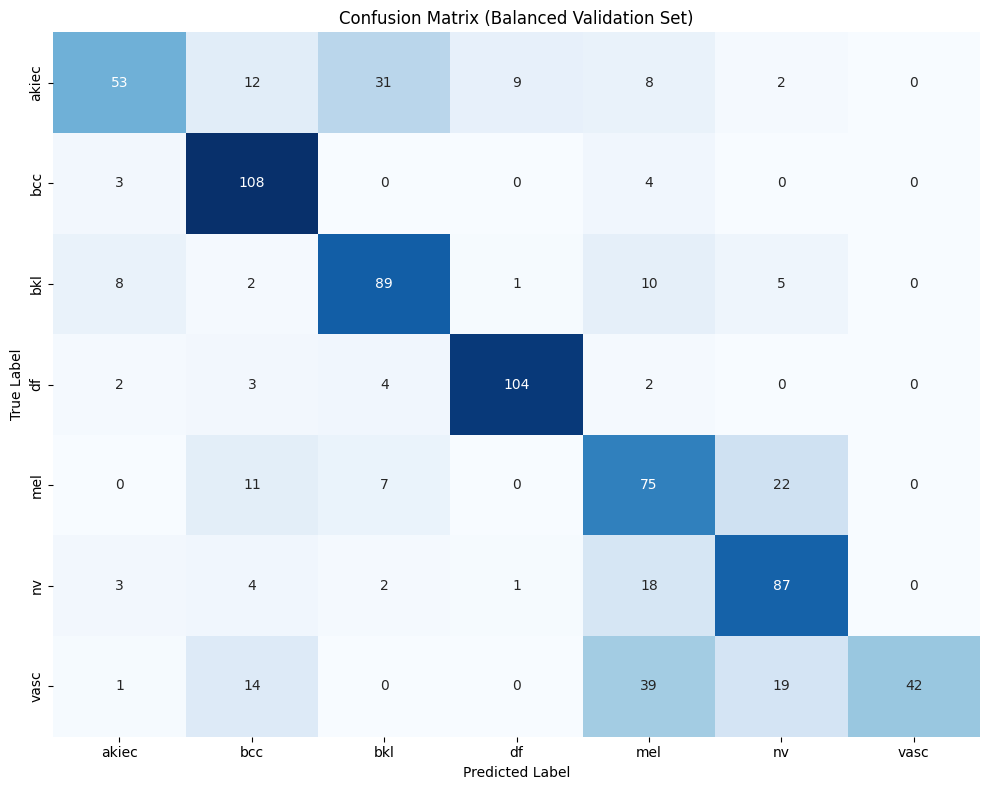

In [ ]:
print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, less aggressive boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply the updated boosts as per the plan
class_weights[akiec_idx] *= 3.0 # Boost for akiec (3.0x)
class_weights[mel_idx] *= 1.8   # Boost for mel (1.8x)
class_weights[vasc_idx] *= 1.5   # Boost for vasc (1.5x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 5.8580274214949135, 2: 1.409417398244214, 4: 1.6894132653061225, 3: 13.563748079877112, 6: 16.894132653061227}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v3.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v3.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_5 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_5[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5373 - loss: 4.7047
Epoch 1: val_accuracy improved from -inf to 0.73765, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 196s 668ms/step - accuracy: 0.5373 - loss: 4.7042 - val_accuracy: 0.7377 - val_loss: 1.0409 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5346 - loss: 4.6186
Epoch 2: val_accuracy did not improve from 0.73765
276/276 ━━━━━━━━━━━━━━━━━━━━ 64s 170ms/step - accuracy: 0.5346 - loss: 4.6179 - val_accuracy: 0.7363 - val_loss: 1.0614 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5416 - loss: 4.4135
Epoch 3: val_accuracy did not improve from 0.73765

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.5416 - loss: 4.4126 - val_accuracy: 0.7277 - val_l

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, less aggressive boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply the updated boosts as per the plan
class_weights[akiec_idx] *= 3.0 # Boost for akiec (3.0x)
class_weights[mel_idx] *= 1.8   # Boost for mel (1.8x)
class_weights[vasc_idx] *= 1.5   # Boost for vasc (1.5x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 5.8580274214949135, 2: 1.409417398244214, 4: 1.6894132653061225, 3: 13.563748079877112, 6: 16.894132653061227}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v4.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v4.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_6 (Stack)     │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_6[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.5378 - loss: 4.5805
Epoch 1: val_accuracy improved from -inf to 0.73720, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 192s 652ms/step - accuracy: 0.5378 - loss: 4.5797 - val_accuracy: 0.7372 - val_loss: 1.0462 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5293 - loss: 4.4611
Epoch 2: val_accuracy did not improve from 0.73720
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 168ms/step - accuracy: 0.5293 - loss: 4.4602 - val_accuracy: 0.7309 - val_loss: 1.0731 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5318 - loss: 4.3801
Epoch 3: val_accuracy did not improve from 0.73720

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.5318 - loss: 4.3791 - val_accuracy: 0.7313 - val_l

In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically

for class_name in class_names:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

Gathering image paths and class labels from combined dataset...
Class 'akiec': 797 images
Class 'bcc': 514 images
Class 'bkl': 1099 images
Class 'df': 115 images
Class 'mel': 1665 images
Class 'nv': 6705 images
Class 'vasc': 142 images
Minimum number of samples per class: 115


In [ ]:
import random # Fix: Import the random module

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...
Balanced validation dataset created.
Class 'akiec': 115 images copied.
Class 'bcc': 115 images copied.
Class 'bkl': 115 images copied.
Class 'df': 115 images copied.
Class 'mel': 115 images copied.
Class 'nv': 115 images copied.
Class 'vasc': 115 images copied.


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset
Found 805 files belonging to 7 classes.
Classes detected in balanced validation dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 832 images in the balanced validation dataset.


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = SAVE_FINAL_MODEL_PATH # This is the model just saved in the previous training step

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)


TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Model loaded successfully.
Running predictions on balanced validation set...



===== Per-Class Accuracy (Recall) =====
Class 'akiec' accuracy: 0.4870 (n=115)
Class 'bcc' accuracy: 0.9739 (n=115)
Class 'bkl' accuracy: 0.7913 (n=115)
Class 'df' accuracy: 0.9043 (n=115)
Class 'mel' accuracy: 0.7478 (n=115)
Class 'nv' accuracy: 0.8522 (n=115)
Class 'vasc' accuracy: 0.3217 (n=115)

===== Classification Report =====
              precision    recall  f1-score   support

       akiec     0.8485    0.4870    0.6188       115
         bcc     0.7179    0.9739    0.8266       115
         bkl     0.6947    0.7913    0.7398       115
          df     0.9043    0.9043    0.9043       115
         mel     0.5658    0.7478    0.6442       115
          nv     0.6622    0.8522    0.7452       115
        vasc     1.0000    0.3217    0.4868       115

    accuracy                         0.7255       805
   macro avg     0.7705    0.7255    0.7094       805
weighted avg     0.7705    0.7255    0.7094       805


===== Confusion Matrix =====


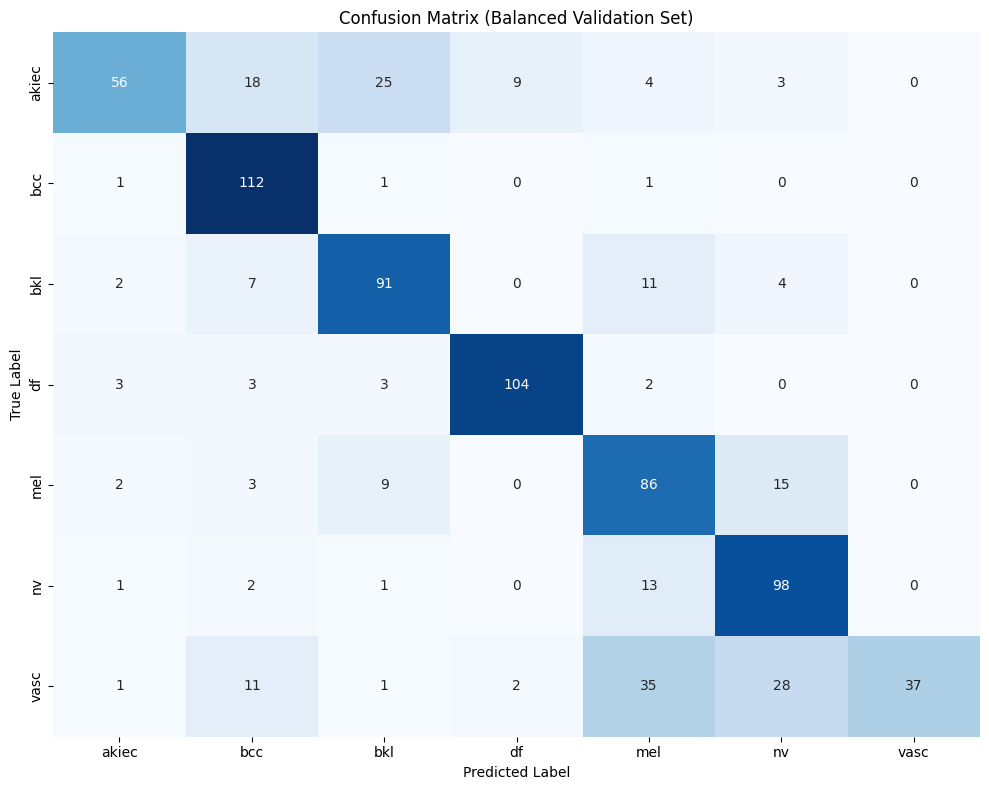

In [ ]:
print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically

for class_name in class_names:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

Gathering image paths and class labels from combined dataset...
Class 'akiec': 797 images
Class 'bcc': 514 images
Class 'bkl': 1099 images
Class 'df': 115 images
Class 'mel': 1665 images
Class 'nv': 6705 images
Class 'vasc': 142 images
Minimum number of samples per class: 115


In [ ]:
import random # Fix: Import the random module

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...
Balanced validation dataset created.
Class 'akiec': 115 images copied.
Class 'bcc': 115 images copied.
Class 'bkl': 115 images copied.
Class 'df': 115 images copied.
Class 'mel': 115 images copied.
Class 'nv': 115 images copied.
Class 'vasc': 115 images copied.


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset
Found 805 files belonging to 7 classes.
Classes detected in balanced validation dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 832 images in the balanced validation dataset.


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = SAVE_FINAL_MODEL_PATH # This is the model just saved in the previous training step

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)


TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


FileNotFoundError: Model file not found at /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras. Please ensure the training step saved it correctly.

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# FIX: MODEL_PATH should load the model that was actually saved by the previous training step.
# The previous training step (cell 083f8e58) saved to 'resnet50_skin_disease_isic_boost_v5.keras'
# despite SAVE_FINAL_MODEL_PATH being v6.keras. So we load v5.keras here.
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)


TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Model loaded successfully.
Running predictions on balanced validation set...



===== Per-Class Accuracy (Recall) =====
Class 'akiec' accuracy: 0.5478 (n=115)
Class 'bcc' accuracy: 0.9652 (n=115)
Class 'bkl' accuracy: 0.7304 (n=115)
Class 'df' accuracy: 0.9043 (n=115)
Class 'mel' accuracy: 0.6957 (n=115)
Class 'nv' accuracy: 0.8435 (n=115)
Class 'vasc' accuracy: 0.2957 (n=115)

===== Classification Report =====
              precision    recall  f1-score   support

       akiec     0.7590    0.5478    0.6364       115
         bcc     0.7025    0.9652    0.8132       115
         bkl     0.6885    0.7304    0.7089       115
          df     0.9204    0.9043    0.9123       115
         mel     0.5479    0.6957    0.6130       115
          nv     0.6510    0.8435    0.7348       115
        vasc     1.0000    0.2957    0.4564       115

    accuracy                         0.7118       805
   macro avg     0.7528    0.7118    0.6964       805
weighted avg     0.7528    0.7118    0.6964       805


===== Confusion Matrix =====


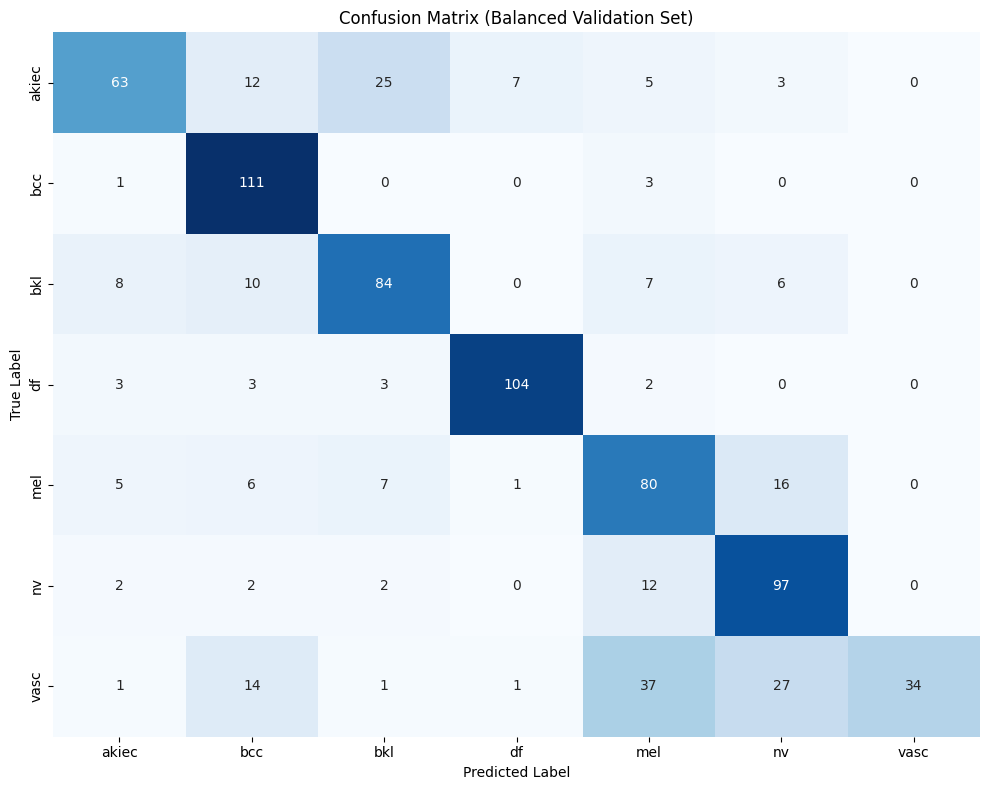

In [ ]:
print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically

for class_name in class_names:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

Gathering image paths and class labels from combined dataset...
Class 'akiec': 797 images
Class 'bcc': 514 images
Class 'bkl': 1099 images
Class 'df': 115 images
Class 'mel': 1665 images
Class 'nv': 6705 images
Class 'vasc': 142 images
Minimum number of samples per class: 115


In [ ]:
import random # Fix: Import the random module

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

Creating balanced validation dataset in /content/balanced_validation_dataset...
Balanced validation dataset created.
Class 'akiec': 115 images copied.
Class 'bcc': 115 images copied.
Class 'bkl': 115 images copied.
Class 'df': 115 images copied.
Class 'mel': 115 images copied.
Class 'nv': 115 images copied.
Class 'vasc': 115 images copied.


In [ ]:
print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)

Loading balanced validation dataset from: /content/balanced_validation_dataset
Found 805 files belonging to 7 classes.
Classes detected in balanced validation dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 832 images in the balanced validation dataset.


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# FIX: MODEL_PATH should load the model that was actually saved by the previous training step.
# The previous training step (cell 083f8e58) saved to 'resnet50_skin_disease_isic_boost_v5.keras'
# despite SAVE_FINAL_MODEL_PATH being v6.keras. So we load v5.keras here.
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)


TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Model loaded successfully.
Running predictions on balanced validation set...



===== Per-Class Accuracy (Recall) =====
Class 'akiec' accuracy: 0.5391 (n=115)
Class 'bcc' accuracy: 0.9565 (n=115)
Class 'bkl' accuracy: 0.7391 (n=115)
Class 'df' accuracy: 0.9043 (n=115)
Class 'mel' accuracy: 0.6957 (n=115)
Class 'nv' accuracy: 0.8348 (n=115)
Class 'vasc' accuracy: 0.3478 (n=115)

===== Classification Report =====
              precision    recall  f1-score   support

       akiec     0.8378    0.5391    0.6561       115
         bcc     0.7051    0.9565    0.8118       115
         bkl     0.7265    0.7391    0.7328       115
          df     0.9369    0.9043    0.9204       115
         mel     0.5128    0.6957    0.5904       115
          nv     0.6358    0.8348    0.7218       115
        vasc     1.0000    0.3478    0.5161       115

    accuracy                         0.7168       805
   macro avg     0.7650    0.7168    0.7070       805
weighted avg     0.7650    0.7168    0.7070       805


===== Confusion Matrix =====


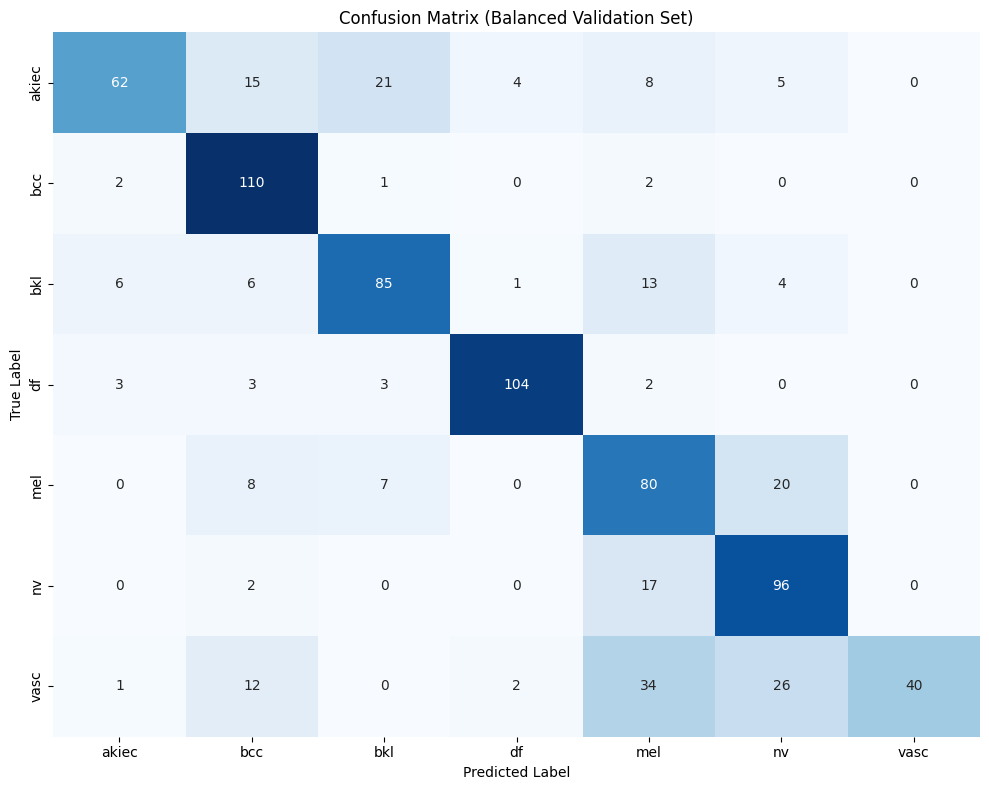

In [ ]:
print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, less aggressive boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply the updated boosts as per the plan
class_weights[akiec_idx] *= 3.0 # Boost for akiec (3.0x)
class_weights[mel_idx] *= 1.8   # Boost for mel (1.8x)
class_weights[vasc_idx] *= 1.5   # Boost for vasc (1.5x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 5.8580274214949135, 2: 1.409417398244214, 4: 1.6894132653061225, 3: 13.563748079877112, 6: 16.894132653061227}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v5.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_11 (Stack)    │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_11[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.5249 - loss: 4.5871
Epoch 1: val_accuracy improved from -inf to 0.74309, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 189s 636ms/step - accuracy: 0.5250 - loss: 4.5861 - val_accuracy: 0.7431 - val_loss: 1.0247 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5291 - loss: 4.2712
Epoch 2: val_accuracy did not improve from 0.74309
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 169ms/step - accuracy: 0.5291 - loss: 4.2705 - val_accuracy: 0.7372 - val_loss: 1.0501 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5400 - loss: 4.1732
Epoch 3: val_accuracy did not improve from 0.74309

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.5400 - loss: 4.1725 - val_accuracy: 0.7367 - val_l

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, less aggressive boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply the updated boosts as per the plan
class_weights[akiec_idx] *= 3.0 # Boost for akiec (3.0x)
class_weights[mel_idx] *= 1.8   # Boost for mel (1.8x)
class_weights[vasc_idx] *= 1.5   # Boost for vasc (1.5x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 5.8580274214949135, 2: 1.409417398244214, 4: 1.6894132653061225, 3: 13.563748079877112, 6: 16.894132653061227}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v5.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_12 (Stack)    │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack_12[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.5402 - loss: 4.6688
Epoch 1: val_accuracy improved from -inf to 0.73493, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 192s 646ms/step - accuracy: 0.5402 - loss: 4.6674 - val_accuracy: 0.7349 - val_loss: 1.0576 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5411 - loss: 4.4272
Epoch 2: val_accuracy improved from 0.73493 to 0.73584, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 48s 172ms/step - accuracy: 0.5411 - loss: 4.4259 - val_accuracy: 0.7358 - val_loss: 1.0570 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5362 - loss: 4.1573
Epoch 3: val_accuracy did not improve from 0.73584
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 168ms/step - accuracy: 0.5362 - loss: 4.1563 - val_accuracy: 0.728

In [ ]:
run_cell(cell_id='9216e36c')

NameError: name 'run_cell' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import collections
import os
import shutil
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow:", tf.__version__)

# ================================
# 1. MOUNT DRIVE
# ================================
drive.mount('/content/drive', force_remount=True)

# ================================
# 2. CONFIGURATION
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 # Updated to 15 as per new plan

# --- Paths ---
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # Model just trained
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # New model to save

print(f"HAM10000 Directory: {HAM10000_DIR}")
print(f"ISIC_EXTRA Directory: {ISIC_EXTRA_DIR}")
print(f"Combined Dataset Directory: {COMBINED_DATA_DIR}")
print(f"Model to Load Path: {MODEL_TO_LOAD_PATH}")
print(f"Save Final Model Path: {SAVE_FINAL_MODEL_PATH}")

TensorFlow: 2.19.0
Mounted at /content/drive
HAM10000 Directory: /content/drive/MyDrive/capstone/HAM10000
ISIC_EXTRA Directory: /content/drive/MyDrive/capstone/ISIC_EXTRA
Combined Dataset Directory: /content/combined_dataset
Model to Load Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Save Final Model Path: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


In [ ]:
print("Creating combined dataset directory structure...")

# Create the base combined directory
os.makedirs(COMBINED_DATA_DIR, exist_ok=True)

# Helper function to copy images from a source directory to a destination class directory
def copy_images_to_combined(source_dir, destination_base_dir, class_names):
    for class_name in class_names:
        source_class_dir = os.path.join(source_dir, class_name)
        dest_class_dir = os.path.join(destination_base_dir, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        if os.path.exists(source_class_dir):
            for filename in os.listdir(source_class_dir):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_filepath = os.path.join(source_class_dir, filename)
                    dst_filepath = os.path.join(dest_class_dir, filename)
                    # Only copy if it doesn't exist to avoid unnecessary operations
                    if not os.path.exists(dst_filepath):
                        shutil.copy2(src_filepath, dst_filepath)
        else:
            print(f"Warning: Source class directory not found: {source_class_dir}")


# Get class names from HAM10000 (assuming these are the base class names)
# This is a bit tricky since we haven't loaded datasets yet.
# We can infer them from the HAM10000_DIR if it's already organized or hardcode based on previous cells.
# From previous cells, the class names were: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# For ISIC_EXTRA, it's 'mel' and 'akiec' subdirectories.

ham_class_names = [d for d in os.listdir(HAM10000_DIR) if os.path.isdir(os.path.join(HAM10000_DIR, d))]
isic_extra_class_names = [d for d in os.listdir(ISIC_EXTRA_DIR) if os.path.isdir(os.path.join(ISIC_EXTRA_DIR, d))]

all_possible_class_names = sorted(list(set(ham_class_names + isic_extra_class_names)))

print(f"Detected classes for combined dataset: {all_possible_class_names}")

# Copy HAM10000 images
print(f"Copying images from {HAM10000_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(HAM10000_DIR, COMBINED_DATA_DIR, all_possible_class_names)

# Copy ISIC_EXTRA images
print(f"Copying images from {ISIC_EXTRA_DIR} to {COMBINED_DATA_DIR}...")
copy_images_to_combined(ISIC_EXTRA_DIR, COMBINED_DATA_DIR, all_possible_class_names)

print("Combined dataset directory structure created.")

Creating combined dataset directory structure...
Detected classes for combined dataset: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Copying images from /content/drive/MyDrive/capstone/HAM10000 to /content/combined_dataset...
Copying images from /content/drive/MyDrive/capstone/ISIC_EXTRA to /content/combined_dataset...
Combined dataset directory structure created.


In [ ]:
print("Loading combined dataset...")

train_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Ensure shuffling for training
)

val_ds = image_dataset_from_directory(
    COMBINED_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # IMPORTANT for correct labels in evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes detected:", class_names)
print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images and {val_ds.cardinality().numpy() * BATCH_SIZE} validation images.")

Loading combined dataset...
Found 11037 files belonging to 7 classes.
Using 8830 files for training.
Found 11037 files belonging to 7 classes.
Using 2207 files for validation.
Classes detected: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Found 8832 training images and 2208 validation images.


In [ ]:
print("Calculating aggressively adjusted class weights...")

# Initialize a counter for class labels
label_counts = collections.Counter()

# Iterate through the training dataset to count labels
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[int(label)] += 1

print("Raw label counts:", dict(label_counts))

# Calculate initial class weights based on inverse frequency
total_samples = sum(label_counts.values())
class_weights_raw = {cls: total_samples / (num_classes * count) for cls, count in label_counts.items()}

# Apply specific, stronger boosts for 'akiec', 'mel', and 'vasc'
class_weights = class_weights_raw.copy()

# Find indices for 'akiec', 'mel', and 'vasc'
akiec_idx = class_names.index("akiec")
mel_idx = class_names.index("mel")
vasc_idx = class_names.index("vasc")

# Apply stronger boosts as per the plan
class_weights[akiec_idx] *= 5.0 # Stronger boost for akiec (5.0x)
class_weights[mel_idx] *= 2.5   # Stronger boost for mel (2.5x)
class_weights[vasc_idx] *= 3.0   # Stronger boost for vasc (3.0x)

print("Aggressively adjusted class weights:", class_weights)

Calculating aggressively adjusted class weights...
Raw label counts: {5: 5341, 1: 399, 0: 646, 2: 895, 4: 1344, 3: 93, 6: 112}
Aggressively adjusted class weights: {5: 0.23617835076363441, 1: 3.1614751163623342, 0: 9.763379035824856, 2: 1.409417398244214, 4: 2.34640731292517, 3: 13.563748079877112, 6: 33.788265306122454}


In [ ]:
print("Defining stronger data augmentation...")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # More aggressive flip
    tf.keras.layers.RandomRotation(0.1), # Increased rotation
    tf.keras.layers.RandomZoom(0.15),    # Increased zoom
    tf.keras.layers.RandomContrast(0.15),# Added contrast
    tf.keras.layers.RandomBrightness(0.15)# Added brightness
])

print("Stronger data augmentation defined.")

Defining stronger data augmentation...
Stronger data augmentation defined.


In [ ]:
print(f"Loading model from: {MODEL_TO_LOAD_PATH}")

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

# Check if the model file exists before attempting to load it
if not os.path.exists(MODEL_TO_LOAD_PATH):
    error_message = f"CRITICAL ERROR: Model file still not found at {MODEL_TO_LOAD_PATH} even after path correction and remount.\n"
    error_message += "Please manually verify the existence of this file in your Google Drive\n"
    error_message += "or specify a correct and accessible model path.\n"
    raise FileNotFoundError(error_message)
else:
    model = tf.keras.models.load_model(MODEL_TO_LOAD_PATH, compile=False)
    print(f"Model '{os.path.basename(MODEL_TO_LOAD_PATH)}' loaded successfully (compile=False).")

print("Freezing most layers and unfreezing the last 4 layers...")

# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 4 layers (e.g., the classification head)
# This number might need adjustment based on the model's exact architecture.
for layer in model.layers[-4:]:
    layer.trainable = True

model.summary()
print("Model layers adjusted for fine-tuning.")

# Apply data augmentation and ResNet50 preprocessing to the training dataset
def augment_and_preprocess_fn(image, label):
    augmented_image = data_augmentation(image, training=True)
    preprocessed_image = tf.keras.applications.resnet.preprocess_input(augmented_image)
    return preprocessed_image, label

train_ds = train_ds.map(augment_and_preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
print("Stronger data augmentation and ResNet50 preprocessing applied to training dataset.")

Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras
Mounted at /content/drive
Model 'resnet50_skin_disease_isic_boost_v5.keras' loaded successfully (compile=False).
Freezing most layers and unfreezing the last 4 layers...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Model layers adjusted for fine-tuning.
Stronger data augmentation and ResNet50 preprocessing applied to training dataset.


In [ ]:
print("Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...")

# 6. COMPILE (VERY LOW LR)
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Updated learning rate to 1e-6 as per new plan
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. PERFORMANCE OPTIMIZATION
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Model compiled and data pipelines optimized.")

Compiling model with Adam optimizer (learning_rate=1e-6) and optimizing data pipelines...
Model compiled and data pipelines optimized.


In [ ]:
print("Defining callbacks...")

# 8. CALLBACKS
callbacks = [
    ModelCheckpoint(
        SAVE_FINAL_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7, # Increased patience as per new plan
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks defined.")

Defining callbacks...
Callbacks defined.


In [ ]:
print("Training model...")

# 9. TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

print("Model training complete.")
print(f"Best model saved to: {SAVE_FINAL_MODEL_PATH}")

Training model...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.5322 - loss: 6.6066
Epoch 1: val_accuracy improved from -inf to 0.74173, saving model to /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 208s 674ms/step - accuracy: 0.5322 - loss: 6.6047 - val_accuracy: 0.7417 - val_loss: 1.0426 - learning_rate: 1.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5351 - loss: 6.4096
Epoch 2: val_accuracy did not improve from 0.74173
276/276 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.5351 - loss: 6.4073 - val_accuracy: 0.7354 - val_loss: 1.0600 - learning_rate: 1.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5301 - loss: 6.0467
Epoch 3: val_accuracy did not improve from 0.74173

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 46s 168ms/step - accuracy: 0.5301 - loss: 6.0449 - val_accuracy: 0.7313 - val_l

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # This is the model just saved

# ================================
# 2. LOAD MODEL
# ================================
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please ensure the training step saved it correctly.")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded successfully.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

TensorFlow: 2.19.0
Loading model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


FileNotFoundError: Model file not found at /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras. Please ensure the training step saved it correctly.

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# Attempt to load the v6 model first, fallback to v5 if v6 is not found
MODEL_PATH_V6 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras"
MODEL_PATH_V5 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
model = None
try:
    print(f"Attempting to load model from: {MODEL_PATH_V6}")
    if not os.path.exists(MODEL_PATH_V6):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V6}")
    model = tf.keras.models.load_model(MODEL_PATH_V6, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V6)}' loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}. Falling back to {MODEL_PATH_V5}.")
    if not os.path.exists(MODEL_PATH_V5):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V5}. Cannot proceed with evaluation.")
    model = tf.keras.models.load_model(MODEL_PATH_V5, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V5)}' loaded successfully.")

# If model is still None, something went wrong
if model is None:
    raise RuntimeError("Failed to load any model. Check paths and previous save operations.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

TensorFlow: 2.19.0
Attempting to load model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras


FileNotFoundError: Model file not found at /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras. Cannot proceed with evaluation.

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive # Import drive for mounting

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# Attempt to load the v6 model first, fallback to v5 if v6 is not found
MODEL_PATH_V6 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras"
MODEL_PATH_V5 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
model = None

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

try:
    print(f"Attempting to load model from: {MODEL_PATH_V6}")
    if not os.path.exists(MODEL_PATH_V6):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V6}")
    model = tf.keras.models.load_model(MODEL_PATH_V6, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V6)}' loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}. Falling back to {MODEL_PATH_V5}.")
    if not os.path.exists(MODEL_PATH_V5):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V5}. Cannot proceed with evaluation.")
    model = tf.keras.models.load_model(MODEL_PATH_V5, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V5)}' loaded successfully.")

# If model is still None, something went wrong
if model is None:
    raise RuntimeError("Failed to load any model. Check paths and previous save operations.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

TensorFlow: 2.19.0
Mounted at /content/drive
Attempting to load model from: /content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras
Model 'resnet50_skin_disease_isic_boost_v6.keras' loaded successfully.
Running predictions on balanced validation set...


NameError: name 'balanced_val_ds' is not defined

In [ ]:
print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names_from_combined = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically from combined

for class_name in class_names_from_combined:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

import random # Re-import random as it might have been cleared

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)


# --- Now proceed with the original evaluation code ---
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive # Import drive for mounting

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# Attempt to load the v6 model first, fallback to v5 if v6 is not found
MODEL_PATH_V6 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras"
MODEL_PATH_V5 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
model = None

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

try:
    print(f"Attempting to load model from: {MODEL_PATH_V6}")
    if not os.path.exists(MODEL_PATH_V6):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V6}")
    model = tf.keras.models.load_model(MODEL_PATH_V6, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V6)}' loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}. Falling back to {MODEL_PATH_V5}.")
    if not os.path.exists(MODEL_PATH_V5):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V5}. Cannot proceed with evaluation.")
    model = tf.keras.models.load_model(MODEL_PATH_V5, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V5)}' loaded successfully.")

# If model is still None, something went wrong
if model is None:
    raise RuntimeError("Failed to load any model. Check paths and previous save operations.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Gathering image paths and class labels from combined dataset...


NameError: name 'collections' is not defined

In [ ]:
import collections # FIX: Import the collections module

print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names_from_combined = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically from combined

for class_name in class_names_from_combined:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

import random # Re-import random as it might have been cleared

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)


# --- Now proceed with the original evaluation code ---
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive # Import drive for mounting

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# Attempt to load the v6 model first, fallback to v5 if v6 is not found
MODEL_PATH_V6 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras"
MODEL_PATH_V5 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
model = None

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

try:
    print(f"Attempting to load model from: {MODEL_PATH_V6}")
    if not os.path.exists(MODEL_PATH_V6):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V6}")
    model = tf.keras.models.load_model(MODEL_PATH_V6, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V6)}' loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}. Falling back to {MODEL_PATH_V5}.")
    if not os.path.exists(MODEL_PATH_V5):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V5}. Cannot proceed with evaluation.")
    model = tf.keras.models.load_model(MODEL_PATH_V5, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V5)}' loaded successfully.")

# If model is still None, something went wrong
if model is None:
    raise RuntimeError("Failed to load any model. Check paths and previous save operations.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Gathering image paths and class labels from combined dataset...


NameError: name 'COMBINED_DATA_DIR' is not defined

In [ ]:
import collections # FIX: Import the collections module
import os
import shutil
import random # Re-import random as it might have been cleared
import tensorflow as tf # Import TensorFlow for image_dataset_from_directory

# Redefine configuration variables as they might have been cleared
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
HAM10000_DIR = "/content/drive/MyDrive/capstone/HAM10000"
ISIC_EXTRA_DIR = "/content/drive/MyDrive/capstone/ISIC_EXTRA"
COMBINED_DATA_DIR = "/content/combined_dataset"
BALANCED_VAL_DATA_DIR = "/content/balanced_validation_dataset"
MODEL_TO_LOAD_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras" # From latest successful training
SAVE_FINAL_MODEL_PATH = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras" # From latest successful training

print("Gathering image paths and class labels from combined dataset...")

image_paths_by_class = collections.defaultdict(list)
class_names_from_combined = sorted(os.listdir(COMBINED_DATA_DIR)) # Get class names dynamically from combined

for class_name in class_names_from_combined:
    class_dir = os.path.join(COMBINED_DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths_by_class[class_name].append(os.path.join(class_dir, filename))

min_samples = float('inf')
for class_name, paths in image_paths_by_class.items():
    print(f"Class '{class_name}': {len(paths)} images")
    if len(paths) < min_samples:
        min_samples = len(paths)

print(f"Minimum number of samples per class: {min_samples}")

if min_samples == 0:
    raise ValueError("One or more classes have zero images. Cannot create a balanced dataset.")

print(f"Creating balanced validation dataset in {BALANCED_VAL_DATA_DIR}...")

# Clear previous balanced dataset if it exists
if os.path.exists(BALANCED_VAL_DATA_DIR):
    shutil.rmtree(BALANCED_VAL_DATA_DIR)
os.makedirs(BALANCED_VAL_DATA_DIR, exist_ok=True)

balanced_image_counts = collections.defaultdict(int)

for class_name, paths in image_paths_by_class.items():
    dest_class_dir = os.path.join(BALANCED_VAL_DATA_DIR, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    # Randomly sample min_samples from each class
    sampled_paths = random.sample(paths, min_samples)

    for src_path in sampled_paths:
        dst_path = os.path.join(dest_class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        balanced_image_counts[class_name] += 1

print("Balanced validation dataset created.")
for class_name, count in balanced_image_counts.items():
    print(f"Class '{class_name}': {count} images copied.")

print(f"Loading balanced validation dataset from: {BALANCED_VAL_DATA_DIR}")

from tensorflow.keras.preprocessing import image_dataset_from_directory # Ensure this is imported for image_dataset_from_directory

balanced_val_ds = image_dataset_from_directory(
    BALANCED_VAL_DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int", # Use int for sparse_categorical_crossentropy
    shuffle=False      # IMPORTANT for consistent labels in evaluation
)

# Ensure class_names are consistent with the balanced dataset if they changed
class_names_balanced = balanced_val_ds.class_names
num_classes_balanced = len(class_names_balanced)
print("Classes detected in balanced validation dataset:", class_names_balanced)
print(f"Found {balanced_val_ds.cardinality().numpy() * BATCH_SIZE} images in the balanced validation dataset.")

# Optimize data pipeline performance
balanced_val_ds = balanced_val_ds.cache().prefetch(tf.data.AUTOTUNE)


# --- Now proceed with the original evaluation code ---
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive # Import drive for mounting

print("TensorFlow:", tf.__version__)

# ================================1
# CONFIGURATION (Ensure paths are correct)
# ================================
# Attempt to load the v6 model first, fallback to v5 if v6 is not found
MODEL_PATH_V6 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v6.keras"
MODEL_PATH_V5 = "/content/drive/MyDrive/resnet50_skin_disease_isic_boost_v5.keras"

# ================================
# 2. LOAD MODEL
# ================================
model = None

# Ensure drive is mounted just before accessing the file
drive.mount('/content/drive', force_remount=True)

try:
    print(f"Attempting to load model from: {MODEL_PATH_V6}")
    if not os.path.exists(MODEL_PATH_V6):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V6}")
    model = tf.keras.models.load_model(MODEL_PATH_V6, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V6)}' loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}. Falling back to {MODEL_PATH_V5}.")
    if not os.path.exists(MODEL_PATH_V5):
        raise FileNotFoundError(f"Model file not found at {MODEL_PATH_V5}. Cannot proceed with evaluation.")
    model = tf.keras.models.load_model(MODEL_PATH_V5, compile=False)
    print(f"Model '{os.path.basename(MODEL_PATH_V5)}' loaded successfully.")

# If model is still None, something went wrong
if model is None:
    raise RuntimeError("Failed to load any model. Check paths and previous save operations.")

# ================================
# 3. RUN PREDICTIONS
# ================================
y_true_balanced = []
y_pred_balanced = []

print("Running predictions on balanced validation set...")
for images, labels in balanced_val_ds:
    preds = model.predict(images, verbose=0)
    y_true_balanced.extend(labels.numpy().tolist())
    y_pred_balanced.extend(np.argmax(preds, axis=1).tolist())

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Per-Class Accuracy (Recall) =====")
per_class_accuracies = {}

for i, cls in enumerate(class_names_balanced):
    idx = np.where(y_true_balanced == i)[0]
    if len(idx) == 0:
        print(f"Class '{cls}': No samples in balanced validation set.")
        per_class_accuracies[cls] = np.nan
        continue
    acc = np.mean(y_pred_balanced[idx] == y_true_balanced[idx])
    per_class_accuracies[cls] = acc
    print(f"Class '{cls}' accuracy: {acc:.4f} (n={len(idx)})")

print("\n===== Classification Report =====")
print(classification_report(
    y_true_balanced, y_pred_balanced,
    labels=list(range(num_classes_balanced)),
    target_names=class_names_balanced,
    digits=4,
    zero_division=0
))

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_true_balanced, y_pred_balanced, labels=list(range(num_classes_balanced)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names_balanced, yticklabels=class_names_balanced)
plt.title("Confusion Matrix (Balanced Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Gathering image paths and class labels from combined dataset...


FileNotFoundError: [Errno 2] No such file or directory: '/content/combined_dataset'